In [4]:
import pandas as pd 
df=pd.read_csv('../data/customer_support_tickets.csv')

In [ ]:
# df=df.dropna()
# df.shape

(2769, 17)

In [ ]:
# df.to_csv('../data/tickets_power_bi.csv', index=False,encoding='utf-8')

In [5]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

In [6]:
df.dtypes

Ticket ID                         int64
Customer Name                    object
Customer Email                   object
Customer Age                      int64
Customer Gender                  object
Product Purchased                object
Date of Purchase                 object
Ticket Type                      object
Ticket Subject                   object
Ticket Description               object
Ticket Status                    object
Resolution                       object
Ticket Priority                  object
Ticket Channel                   object
First Response Time              object
Time to Resolution               object
Customer Satisfaction Rating    float64
dtype: object

In [7]:
df.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
X=df[['Customer Age','Customer Gender','Product Purchased','Ticket Channel','Ticket Priority']]

In [10]:
X.dtypes

Customer Age          int64
Customer Gender      object
Product Purchased    object
Ticket Channel       object
Ticket Priority      object
dtype: object

In [13]:
df['Ticket Priority'].value_counts()

Ticket Priority
Medium      2192
Critical    2129
High        2085
Low         2063
Name: count, dtype: int64

In [ ]:
X['Product Purchased'].value_counts()

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [15]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

In [17]:
X_processed = preprocessor.fit_transform(X)

In [18]:
feature_names = preprocessor.get_feature_names_out()

In [19]:
feature_names

array(['num__Customer Age', 'cat__Customer Gender_Female',
       'cat__Customer Gender_Male', 'cat__Customer Gender_Other',
       'cat__Product Purchased_Adobe Photoshop',
       'cat__Product Purchased_Amazon Echo',
       'cat__Product Purchased_Amazon Kindle',
       'cat__Product Purchased_Apple AirPods',
       'cat__Product Purchased_Asus ROG',
       'cat__Product Purchased_Autodesk AutoCAD',
       'cat__Product Purchased_Bose QuietComfort',
       'cat__Product Purchased_Bose SoundLink Speaker',
       'cat__Product Purchased_Canon DSLR Camera',
       'cat__Product Purchased_Canon EOS',
       'cat__Product Purchased_Dell XPS',
       'cat__Product Purchased_Dyson Vacuum Cleaner',
       'cat__Product Purchased_Fitbit Charge',
       'cat__Product Purchased_Fitbit Versa Smartwatch',
       'cat__Product Purchased_Garmin Forerunner',
       'cat__Product Purchased_GoPro Action Camera',
       'cat__Product Purchased_GoPro Hero',
       'cat__Product Purchased_Google Nest',
 

In [21]:
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

In [22]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
X = X_processed_df

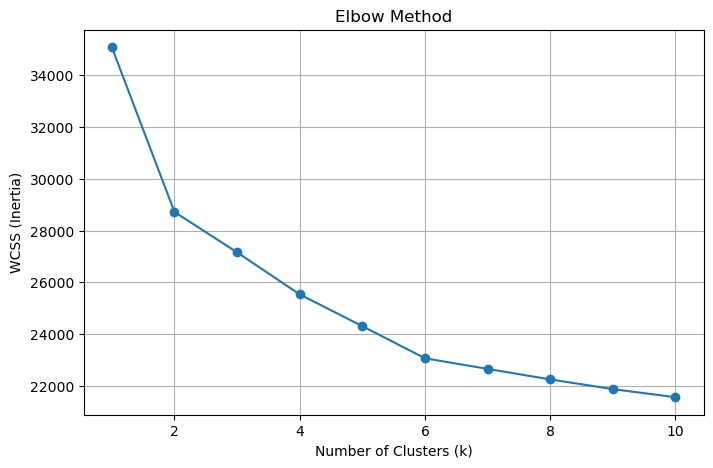

In [24]:
# Elbow Method
wcss = []  # Within-Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

In [27]:
optimal_k = 6

kmeans = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X)

# Add cluster labels to dataframe
df['Cluster'] = cluster_labels

print(df.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [28]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating', 'Cluster'],
      dtype='object')

In [26]:
silhouette_scores = []

for k in range(2, 8):  # silhouette score requires at least 2 clusters
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)

    silhouette_scores.append(score)
    print(f"k={k}, Silhouette Score={score:.4f}")

best_k = range(2, 8)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k based on Silhouette Score: {best_k}")

k=2, Silhouette Score=0.1583
k=3, Silhouette Score=0.1123
k=4, Silhouette Score=0.1240
k=5, Silhouette Score=0.1115
k=6, Silhouette Score=0.1251
k=7, Silhouette Score=0.1121

Best k based on Silhouette Score: 2


In [29]:
df.to_csv('../data/segmentation.csv', index=False,encoding='utf-8')